In [111]:
import os
import dask
import glob
import pyproj
import cmocean
import cartopy.feature as cfeature
from pyproj import Transformer
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

ProgressBar().register()

In [103]:
for file_path in glob.glob('/pscratch/sd/s/skygale/pbi-data/*.nc'):
    print(file_path)
    ds = xr.open_dataset(file_path)
    print(ds.dims)

/pscratch/sd/s/skygale/pbi-data/AMSR2_25km_2012_2024.nc
FrozenMappingWarningOnValuesAccess({'ni': 304, 'nj': 448, 'time': 4806})
/pscratch/sd/s/skygale/pbi-data/G10016_PROTO_25km_2025.nc
FrozenMappingWarningOnValuesAccess({'ni': 304, 'nj': 448, 'time': 4806})
/pscratch/sd/s/skygale/pbi-data/AMSR2_12.5km_2012_Present.nc
FrozenMappingWarningOnValuesAccess({'ni': 608, 'nj': 896, 'time': 4679})
/pscratch/sd/s/skygale/pbi-data/NSIDC_0803_25km_2023_Present.nc
FrozenMappingWarningOnValuesAccess({'time': 981, 'y': 448, 'x': 304})
/pscratch/sd/s/skygale/pbi-data/G02202_25km_1978_2025.nc
FrozenMappingWarningOnValuesAccess({'time': 17121, 'y': 448, 'x': 304})


In [104]:
ds

<xarray.Dataset> Size: 35GB
Dimensions:                               (time: 17121, y: 448, x: 304)
Coordinates:
  * x                                     (x) float64 2kB -3.838e+06 ... 3.73...
  * y                                     (y) float64 4kB 5.838e+06 ... -5.33...
  * time                                  (time) datetime64[ns] 137kB 1978-10...
Data variables:
    crs                                   (time) int32 68kB ...
    cdr_seaice_conc_interp_spatial_flag   (time, y, x) uint8 2GB ...
    cdr_seaice_conc_qa_flag               (time, y, x) uint8 2GB ...
    cdr_seaice_conc_interp_temporal_flag  (time, y, x) uint8 2GB ...
    cdr_seaice_conc                       (time, y, x) float64 19GB ...
    cdr_seaice_conc_stdev                 (time, y, x) float32 9GB ...
Attributes: (12/46)
    Conventions:               CF-1.11, ACDD-1.3
    date_created:              2024-11-11T23:59:35Z
    time_coverage_start:       1978-10-25T00:00:00Z
    time_coverage_end:         1978-10-25T23:59:59Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D
    ...                        ...
    geospatial_lat_min:        30.980564
    geospatial_lat_max:        90.0
    geospatial_lon_min:        -180.0
    geospatial_lon_max:        180.0
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

In [105]:
ds_sel = ds['cdr_seaice_conc'].isel(time=0)
ds_sel

<xarray.DataArray 'cdr_seaice_conc' (y: 448, x: 304)> Size: 1MB
[136192 values with dtype=float64]
Coordinates:
  * x        (x) float64 2kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y        (y) float64 4kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
    time     datetime64[ns] 8B 1978-10-25
Attributes:
    standard_name:          sea_ice_area_fraction
    coverage_content_type:  image
    units:                  1
    long_name:              NOAA/NSIDC CDR of Passive Microwave Sea Ice Conce...
    grid_mapping:           crs
    ancillary_variables:    cdr_seaice_conc_stdev cdr_seaice_conc_qa_flag
    valid_range:            [  0 100]

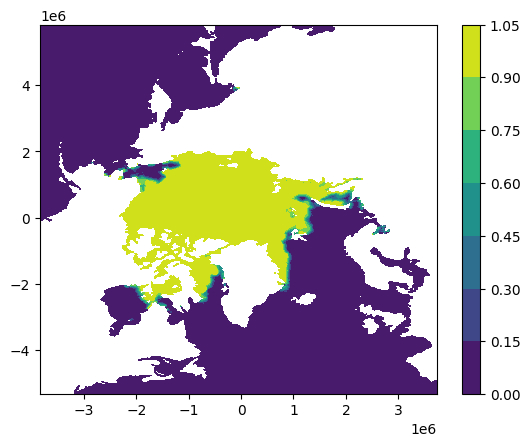

In [106]:
plt.figure()
plt.contourf(ds_sel.x, ds_sel.y, ds_sel)
plt.colorbar()
plt.show()

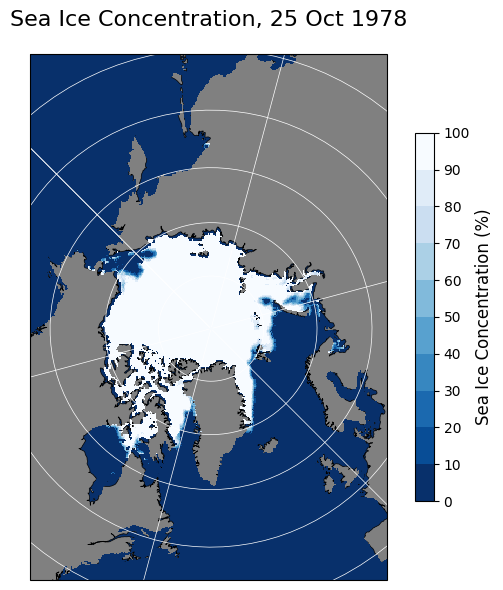

In [148]:
import matplotlib.colors as mcolors

# Define projection and extent
crs = ccrs.Stereographic(central_latitude=90, central_longitude=-45)
extent = (-3850000, 3750000, -5350000, 5850000)

# Define norm
levels = np.arange(0, 105, 10)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': crs})
ax.set_extent(extent, crs=crs)

# Background: land, ocean, coastlines
ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')
ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=1, facecolor='gray', edgecolor='black', linewidth=0.5)

# Plot sea ice concentration as discrete colormap
im = ax.pcolormesh(
    ds.x.values, 
    ds.y.values, 
    ds_sel.values * 100,
    cmap='Blues_r',
    norm=norm,
    transform=crs,
)

# Optional: gridlines
gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='white')

# Colorbar with percentage formatting
cbar = plt.colorbar(im, orientation='vertical', boundaries=levels, ticks=np.linspace(0, 100, 11), pad=0.05, shrink=0.7)
cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

# Title in same style
date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
ax.set_title(f'Sea Ice Concentration, {date_str}', fontsize=16, pad=20)

plt.tight_layout()
plt.show()


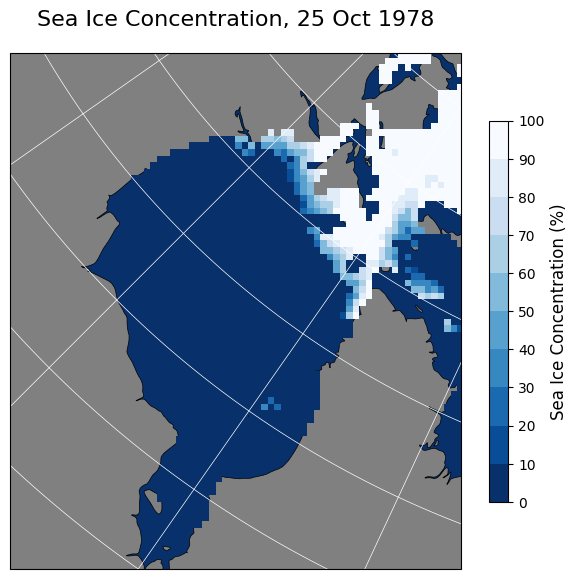

In [167]:
import matplotlib.colors as mcolors

# Define projection
crs = ccrs.Stereographic(central_latitude=90, central_longitude=-45)

# Hudson Bay extent (approximate, in meters)
hudson_lonlat_extent = [-88, -80, 51, 69]  # [lon_min, lon_max, lat_min, lat_max]

# Discrete levels
levels = np.arange(0, 105, 10)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': crs})
ax.set_extent(hudson_lonlat_extent, crs=ccrs.PlateCarree())

# Background
ax.add_feature(cfeature.OCEAN.with_scale('50m'), zorder=0, facecolor='#08306B')
ax.add_feature(cfeature.LAND.with_scale('50m'), zorder=1, facecolor='gray', edgecolor='black', linewidth=0.5)

# Sea ice data (with optional thresholding if needed)
im = ax.pcolormesh(
    ds.x.values, 
    ds.y.values, 
    ds_sel.values * 100,
    cmap='Blues_r',
    norm=norm,
    transform=crs,
)

# Gridlines
gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='white')

# Colorbar
cbar = plt.colorbar(im, orientation='vertical', boundaries=levels,
                    ticks=np.linspace(0, 100, 11), pad=0.05, shrink=0.7)
cbar.set_label('Sea Ice Concentration (%)', fontsize=12)

# Title
date_str = ds_sel["time"].dt.strftime("%d %b %Y").item()
ax.set_title(f'Sea Ice Concentration, {date_str}', fontsize=16, pad=20)

plt.tight_layout()
plt.show()
